In [6]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [11]:
import zipfile
import os
zip_file = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
   zip_ref.extractall("dataset")
print("ZIP extracted successfully!")
print(os.listdir("dataset"))

ZIP extracted successfully!
['Water Quality Classification for Rural Areas.csv']


In [12]:
import glob
import pandas as pd
csv_files = glob.glob("dataset/**/*.csv", recursive=True)
print("CSV files found:")
print(csv_files)

CSV files found:
['dataset/Water Quality Classification for Rural Areas.csv']


In [13]:
file_path = csv_files[0]
data = pd.read_csv(file_path)
print("Dataset loaded successfully!")
display(data.head())
print("\nShape:")
print(data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset loaded successfully!


,pH,Turbidity_NTU,Temperature_C,TDS_ppm,Conductivity_uS_cm,Dissolved_Oxygen_mg_L,Water_Quality
0,7.42,0.25,16.88,306.7,1486.1,7.41,Good
1,8.18,0.87,20.55,84.3,476.3,6.04,Moderate
2,5.58,1.99,26.25,676.7,479.9,6.71,Poor
3,7.93,0.06,30.15,852.9,713.5,3.24,Poor
4,8.37,3.37,12.32,161.2,1702.6,6.83,Poor



Shape:
(450, 7)

Columns:
['pH', 'Turbidity_NTU', 'Temperature_C', 'TDS_ppm', 'Conductivity_uS_cm', 'Dissolved_Oxygen_mg_L', 'Water_Quality']


In [19]:
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay

In [20]:
file = glob.glob("dataset/**/*.csv", recursive=True)[0]
data = pd.read_csv(file)

In [21]:
X = data.drop("Water_Quality", axis=1)
y = LabelEncoder().fit_transform(data["Water_Quality"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred) * 100, "%")

Accuracy: 94.44444444444444 %


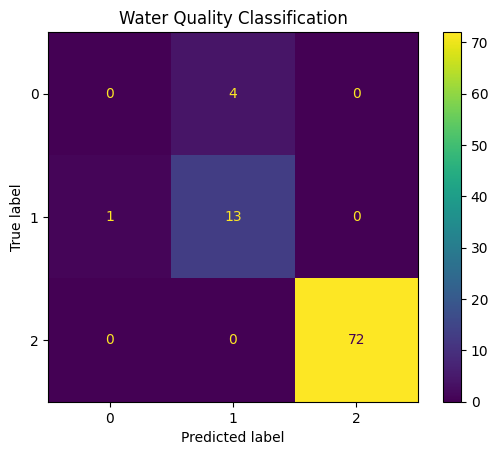

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Water Quality Classification")
plt.show()

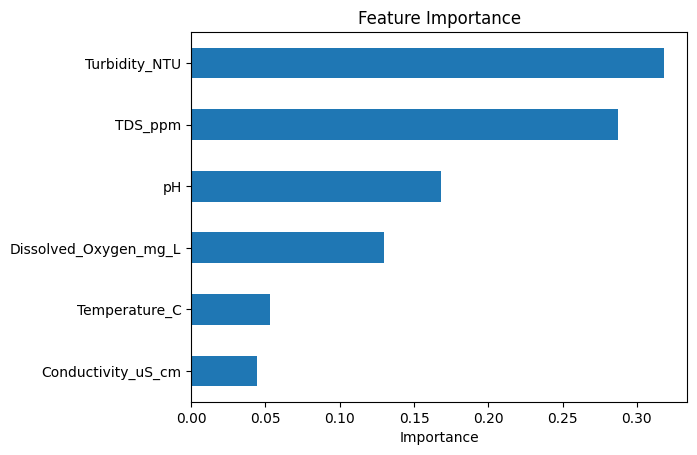

In [23]:
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(
    kind="barh"
)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [24]:
print("\nWater Quality Classification completed successfully!")


Water Quality Classification completed successfully!
